# Closure model with EFFY enrollment

Joins IPEDS 12-month enrollment (EFFY, combined by `scripts/02_combine_effy.py`) onto the F2 feature matrix from notebook 03 and refits the same two baselines. Same cohort (1,836 private nonprofits alive in 2019), same look-back window (2017-2019), same label (`closed_by_2024`).

**New features (8):** total / undergrad enrollment last value, enrollment slope and 3-year pct change, undergrad share, plus per-student ratios (`endowment_per_student`, `revenue_per_student`, `tuition_per_student`).

**Comparison is apples-to-apples:** the F2-only numbers below are recomputed from the saved feature matrix using the exact same CV split as the F2+EFFY run, not lifted from notebook 03.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED = ROOT / "processed_data"

AS_OF = 2019
WINDOW = [2017, 2018, 2019]

f2_feat = pd.read_csv(PROCESSED / "f2_features_asof2019.csv", index_col=0)
effy = pd.read_csv(PROCESSED / "effy_combined.csv")
f2_feat.shape, effy.shape

((1836, 30), (71431, 6))

In [10]:
# Restrict EFFY to the F2 cohort and look-back window.
cohort = set(f2_feat.index)
ef = effy[effy.UNITID.isin(cohort) & effy.year.isin(WINDOW)].copy()
ef["total_enrollment"] = pd.to_numeric(ef["total_enrollment"], errors="coerce")
ef["undergrad_enrollment"] = pd.to_numeric(ef["undergrad_enrollment"], errors="coerce")

covered = ef.UNITID.nunique()
print(f"cohort with EFFY data in window: {covered} of {len(cohort)} ({covered/len(cohort):.1%})")

cohort with EFFY data in window: 1833 of 1836 (99.8%)


In [11]:
# Per-institution enrollment features over the window.
ef_sorted = ef.sort_values(["UNITID", "year"])
last = (
    ef_sorted.groupby("UNITID")[["total_enrollment", "undergrad_enrollment"]]
    .last().add_suffix("__last")
)

def slope(g: pd.DataFrame, col: str) -> float:
    s = g[["year", col]].dropna()
    if len(s) < 2:
        return np.nan
    y = s[col].to_numpy()
    if np.std(y) == 0:
        return 0.0
    return float(np.polyfit(s["year"].to_numpy(), y, 1)[0])

def pct_window(g: pd.DataFrame, col: str) -> float:
    s = g[["year", col]].dropna().sort_values("year")
    if len(s) < 2 or s[col].iloc[0] == 0:
        return np.nan
    return (s[col].iloc[-1] - s[col].iloc[0]) / abs(s[col].iloc[0])

slopes = ef.groupby("UNITID").apply(
    lambda g: pd.Series({"total_enrollment__slope": slope(g, "total_enrollment")}),
    include_groups=False,
)
pct = ef.groupby("UNITID").apply(
    lambda g: pd.Series({"total_enrollment__pct3": pct_window(g, "total_enrollment")}),
    include_groups=False,
)

ef_feat = last.join(slopes).join(pct)
ef_feat["undergrad_share__last"] = (
    ef_feat["undergrad_enrollment__last"]
    / ef_feat["total_enrollment__last"].replace({0: np.nan})
)
ef_feat.shape, ef_feat.columns.tolist()

((1833, 5),
 ['total_enrollment__last',
  'undergrad_enrollment__last',
  'total_enrollment__slope',
  'total_enrollment__pct3',
  'undergrad_share__last'])

In [12]:
# Join enrollment onto the F2 feature matrix and add per-student ratios + log enrollment.
combined = f2_feat.join(ef_feat, how="left")

denom = combined["total_enrollment__last"].replace({0: np.nan})
combined["endowment_per_student"] = combined["endowment_eoy__last"] / denom
combined["revenue_per_student"] = combined["F2D16__last"] / denom
combined["tuition_per_student"] = combined["F2D01__last"] / denom

s = combined["total_enrollment__last"]
combined["log_total_enrollment"] = np.sign(s) * np.log1p(np.abs(s))

combined = combined.replace([np.inf, -np.inf], np.nan)
y = combined["closed_by_2024"].astype(int)
X_full = combined.drop(columns=["closed_by_2024", "as_of_year"])
X_f2only = f2_feat.drop(columns=["closed_by_2024", "as_of_year"]).replace([np.inf, -np.inf], np.nan)

print(f"F2 + EFFY:  {X_full.shape}")
print(f"F2 only:    {X_f2only.shape}")
print(f"label positives: {int(y.sum())} / {len(y)} ({y.mean():.2%})")

F2 + EFFY:  (1836, 37)
F2 only:    (1836, 28)
label positives: 131 / 1836 (7.14%)


In [13]:
# Same two baselines, same CV split, run on both feature sets so the comparison is honest.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_models():
    return {
        "logreg": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "gbt": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(random_state=42)),
        ]),
    }

rows = []
for feature_set, X in [("F2 only", X_f2only), ("F2 + EFFY", X_full)]:
    for name, model in make_models().items():
        auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        ap = cross_val_score(model, X, y, cv=cv, scoring="average_precision")
        rows.append({
            "features": feature_set, "model": name,
            "auc": auc.mean(), "auc_std": auc.std(),
            "ap": ap.mean(), "ap_std": ap.std(),
        })

results = pd.DataFrame(rows).set_index(["features", "model"]).round(3)
results

auc  auc_std     ap  ap_std
features  model                                
F2 only   logreg  0.848    0.026  0.370   0.081
          gbt     0.859    0.034  0.417   0.086
F2 + EFFY logreg  0.858    0.021  0.391   0.076
          gbt     0.859    0.035  0.453   0.099

In [14]:
# Headline deltas: what did adding EFFY actually buy us?
delta = (
    results.unstack("features")
    .swaplevel(axis=1).sort_index(axis=1)
)
for metric in ["auc", "ap"]:
    d = delta["F2 + EFFY"][metric] - delta["F2 only"][metric]
    print(f"{metric.upper()} delta (F2+EFFY minus F2-only):")
    print(d.round(3).to_string())
    print()

AUC delta (F2+EFFY minus F2-only):
model
gbt       0.00
logreg    0.01

AP delta (F2+EFFY minus F2-only):
model
gbt       0.036
logreg    0.021



In [15]:
# GBT feature importances on the full feature set.
gbt = make_models()["gbt"]
gbt.fit(X_full, y)
importances = (
    pd.Series(gbt.named_steps["clf"].feature_importances_, index=X_full.columns)
    .sort_values(ascending=False)
)
importances.head(15)

total_enrollment__pct3          0.117278
assets_to_liabilities__mean3    0.067741
expenses_to_revenue__last       0.066688
F2D16__slope                    0.055352
tuition_dependence              0.050793
F2A02__last                     0.048252
assets_to_liabilities__last     0.043918
total_expenses__pct3            0.041137
operating_margin__mean3         0.040084
total_enrollment__last          0.035538
revenue_per_student             0.035501
tuition_per_student             0.035178
operating_margin__last          0.033822
log_F2A02                       0.031954
expendable_net_assets__pct3     0.029449
dtype: float64

## Plots

Three views of what the model is doing.

1. **GBT training curve** — sklearn's gradient-boosted trees has no "epochs" because each iteration adds one new decision tree to the ensemble (100 trees total by default). The log-loss falls as each new tree corrects the residual error of the previous ones. This is the closest visual analog to a neural-net training curve.
2. **ROC and Precision-Recall curves** — F2-only vs F2+EFFY overlaid, so the lift from adding enrollment is visible at every threshold, not just at the AUC/AP summary numbers.
3. **Top features (with source color)** — bar chart of the GBT's top-15 features, colored by where the feature came from (F2 financial / EFFY enrollment / cross-source ratio).


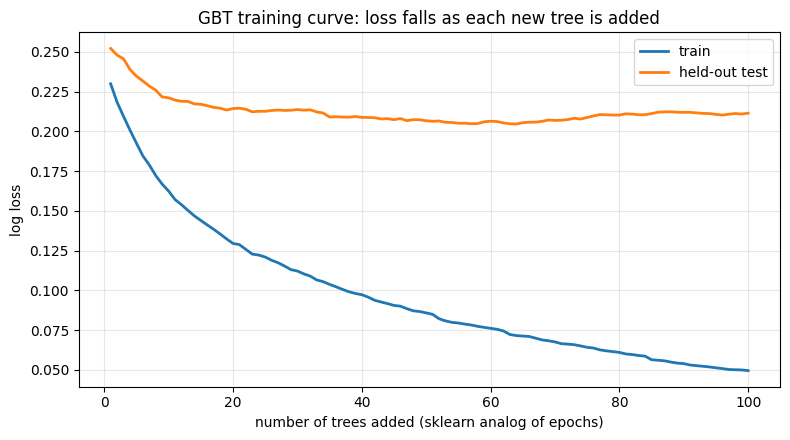

In [16]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier as _GBC
from sklearn.impute import SimpleImputer as _Imp

# Refit the GBT on a single train split with staged_predict_proba enabled so we can
# plot per-tree (per-stage) test log-loss. This is the sklearn analog of "epochs".
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y, test_size=0.25, random_state=42, stratify=y)

imp = _Imp(strategy="median").fit(X_tr)
X_tr_i = imp.transform(X_tr); X_te_i = imp.transform(X_te)

gbc = _GBC(random_state=42).fit(X_tr_i, y_tr)

# staged_predict_proba yields per-stage probabilities; compute log-loss at each stage.
from sklearn.metrics import log_loss
train_loss, test_loss = [], []
for p_tr, p_te in zip(gbc.staged_predict_proba(X_tr_i), gbc.staged_predict_proba(X_te_i)):
    train_loss.append(log_loss(y_tr, p_tr[:, 1]))
    test_loss.append(log_loss(y_te, p_te[:, 1]))

fig, ax = plt.subplots(figsize=(8, 4.5))
stages = range(1, len(train_loss) + 1)
ax.plot(stages, train_loss, label="train", lw=2)
ax.plot(stages, test_loss, label="held-out test", lw=2)
ax.set_xlabel("number of trees added (sklearn analog of epochs)")
ax.set_ylabel("log loss")
ax.set_title("GBT training curve: loss falls as each new tree is added")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


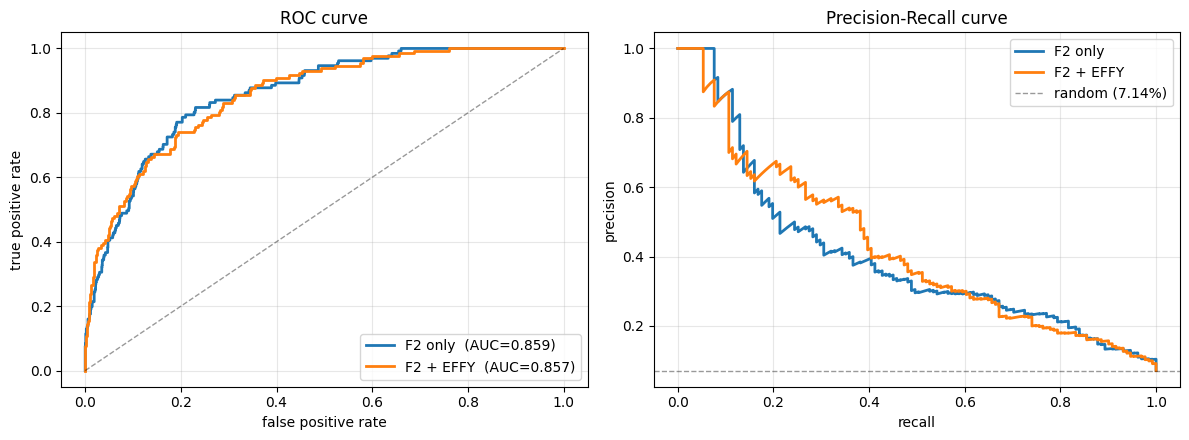

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as _auc
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities for both feature sets, same CV split.
def oof_proba(X):
    return cross_val_predict(make_models()["gbt"], X, y, cv=cv, method="predict_proba")[:, 1]

p_f2  = oof_proba(X_f2only)
p_all = oof_proba(X_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, p, color in [("F2 only", p_f2, "tab:blue"), ("F2 + EFFY", p_all, "tab:orange")]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f"{label}  (AUC={_auc(fpr, tpr):.3f})", color=color, lw=2)
    pr_p, pr_r, _ = precision_recall_curve(y, p)
    axes[1].plot(pr_r, pr_p, label=label, color=color, lw=2)

axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].axhline(y.mean(), color="k", linestyle="--", lw=1, alpha=0.4, label=f"random ({y.mean():.2%})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


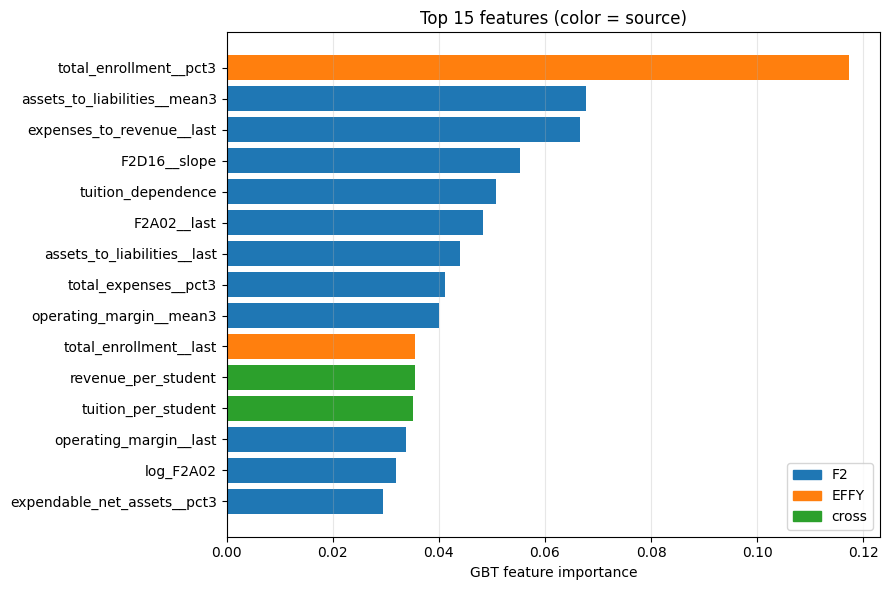

In [18]:
# Top-15 GBT features, color-coded by source so the EFFY contribution is obvious.
EFFY_FEATS = {"total_enrollment__last", "undergrad_enrollment__last",
              "total_enrollment__slope", "total_enrollment__pct3",
              "undergrad_share__last", "log_total_enrollment"}
CROSS_FEATS = {"endowment_per_student", "revenue_per_student", "tuition_per_student"}

def source(name):
    if name in EFFY_FEATS: return "EFFY"
    if name in CROSS_FEATS: return "cross"
    return "F2"

top = importances.head(15).iloc[::-1]
colors_by_source = {"F2": "tab:blue", "EFFY": "tab:orange", "cross": "tab:green"}
bar_colors = [colors_by_source[source(n)] for n in top.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=bar_colors)
ax.set_xlabel("GBT feature importance"); ax.set_title("Top 15 features (color = source)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors_by_source.items()], loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()


In [19]:
# Persist the enriched feature matrix for downstream notebooks.
out = X_full.copy()
out["closed_by_2024"] = y
out["as_of_year"] = AS_OF
out_path = PROCESSED / f"f2_effy_features_asof{AS_OF}.csv"
out.to_csv(out_path)
out_path, out.shape

(PosixPath('/home/tuna-akin/classes-2026/ann-2026/vigiledu/processed_data/f2_effy_features_asof2019.csv'),
 (1836, 39))